In [1]:
import tools.sitnikov_integrator as sit
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from scipy.integrate import solve_ivp


def make_tz_plot(t0, z0, v0, T = 600):
    e = 0.5
    sit.set_eps(e)

    ans = solve_ivp(fun = sit.phase_velocity, 
                    t_span = (t0, t0 + T),
                    y0 = np.array([z0, v0]),
                    dense_output=True
                    )

    plt.plot(ans.t, ans.y[0])
    plt.xlabel("t")
    plt.ylabel("z")
    plt.show()


z0 =  0 v0 =  1.35501623412524 t0 =  2.2884332043604387


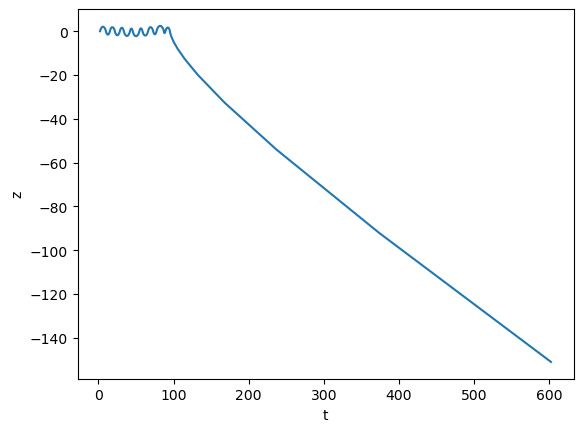

z0 =  0 v0 =  1.837750005667055 t0 =  3.3336538579200705


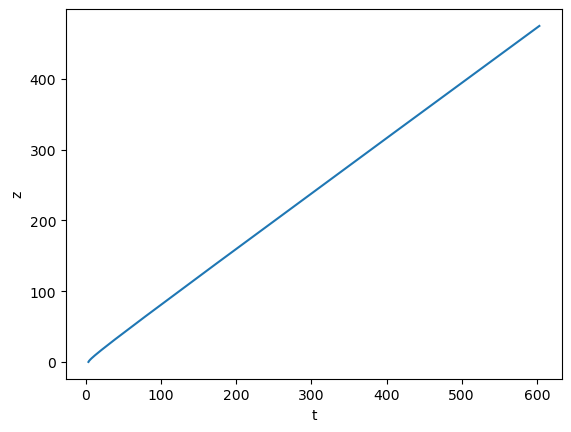

z0 =  0 v0 =  0.4338464243918469 t0 =  2.909777454389765


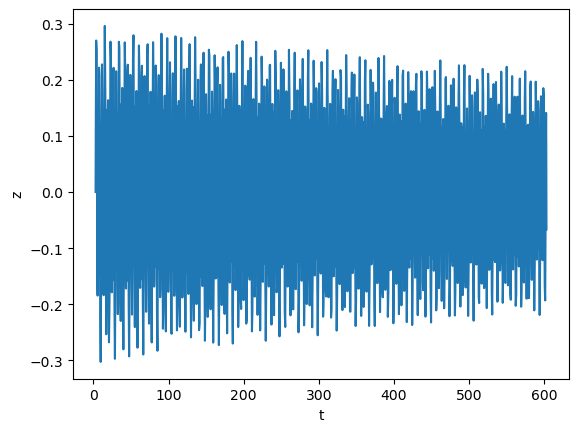

z0 =  0 v0 =  2.2183770988578626 t0 =  5.7803780419298025


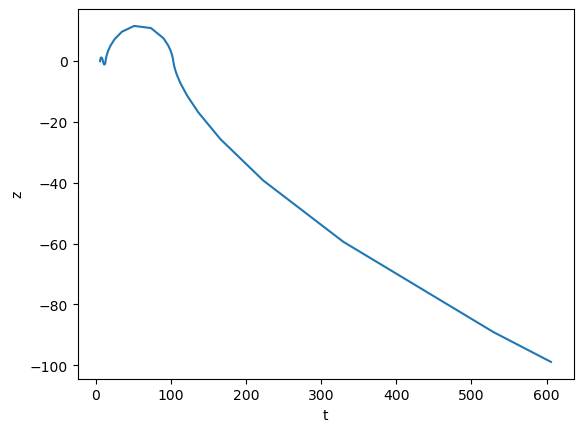

z0 =  0 v0 =  1.2383147043489484 t0 =  5.509440319133253


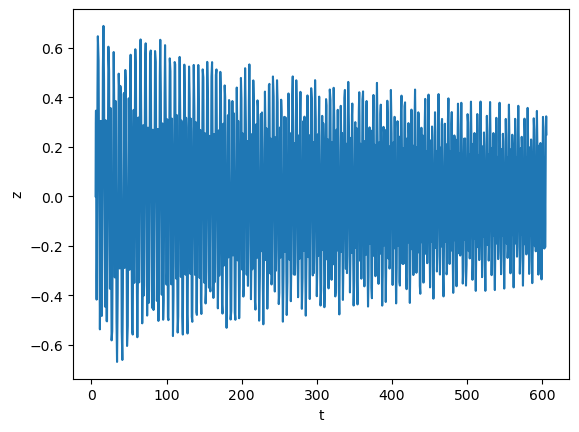

In [20]:
import random
N = 5
for i in range(N):
    z0 = 0
    v0 = 2.5*random.random()
    t0 = 2*np.pi*random.random()
    print("z0 = ", z0, "v0 = ", v0, "t0 = ", t0)
    make_tz_plot(t0,z0,v0)


## Low velocity: v < 1.0, low time, T = 600

z0 =  0 v0 =  0.847402736585724 t0 =  5.289025495056256


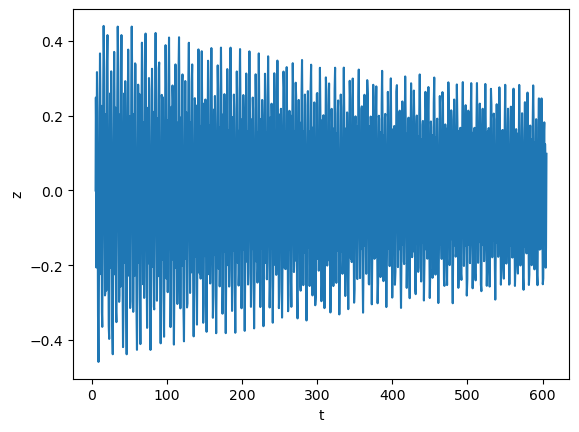

z0 =  0 v0 =  0.685473687424181 t0 =  4.01943262346342


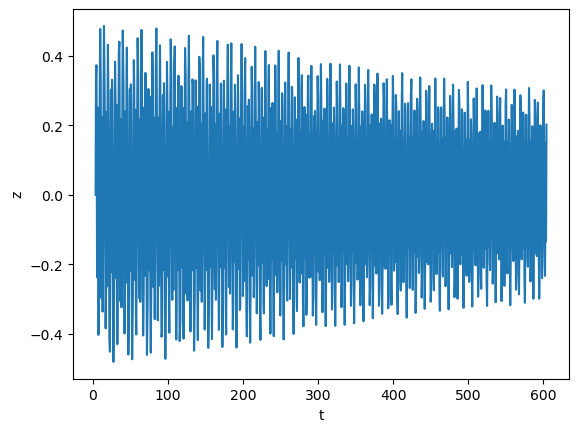

z0 =  0 v0 =  0.0386641334535327 t0 =  3.8688523011648503


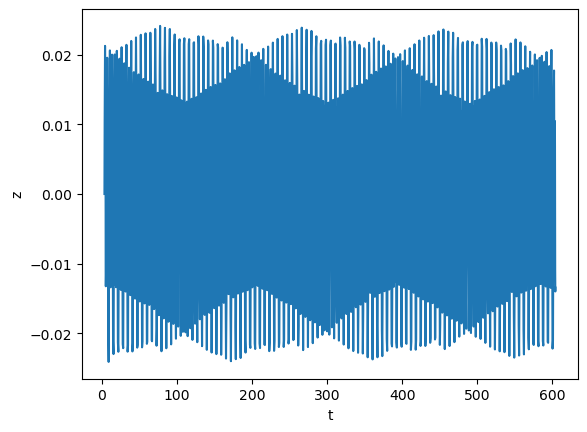

z0 =  0 v0 =  0.801720849136923 t0 =  4.355924389798121


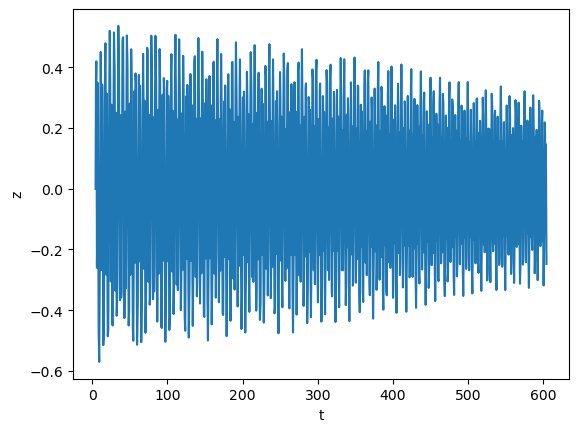

z0 =  0 v0 =  0.8765252436612816 t0 =  4.151723040306713


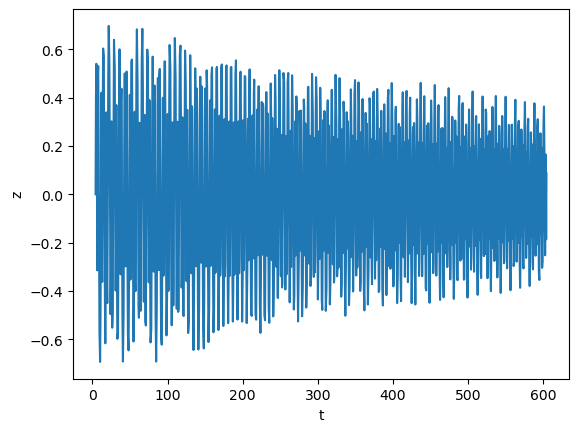

In [25]:
import random
N = 5
for i in range(N):
    z0 = 0
    v0 = 1.0*random.random()
    t0 = 2*np.pi*random.random()
    print("z0 = ", z0, "v0 = ", v0, "t0 = ", t0)
    make_tz_plot(t0,z0,v0)


We have more or less regular behaviour which in any case is clearly bounded. It also seems that the amplitude of oscillation often decreases, but doesn't increase

## Low velocity v < 1.0, Long term T >= 6000

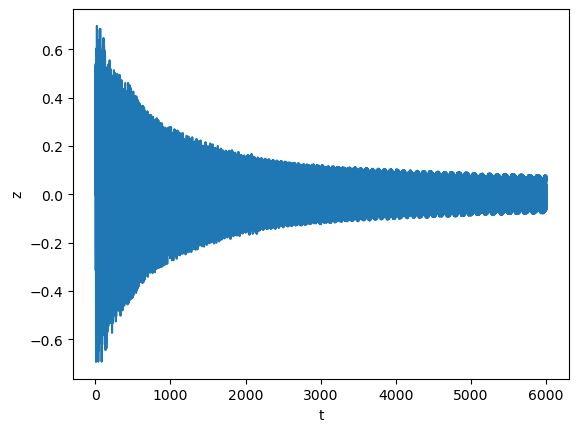

In [26]:
make_tz_plot(t0 =  4.151723040306713, z0 =  0,  v0 =  0.8765252436612816, T = 6000)

We seem to have some converge to lower oscillations

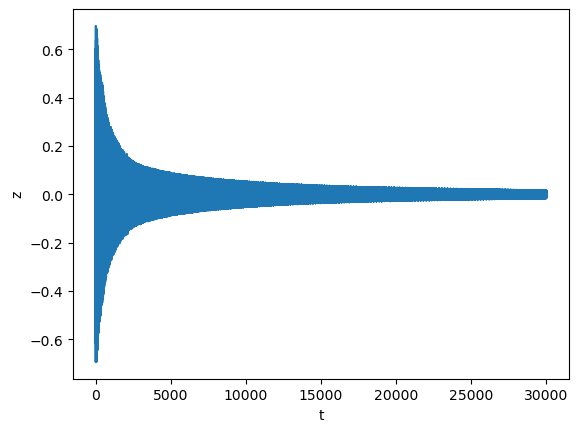

In [27]:
make_tz_plot(t0 =  4.151723040306713, z0 =  0,  v0 =  0.8765252436612816, T = 30000)

We see a collapse towards zero amplitude

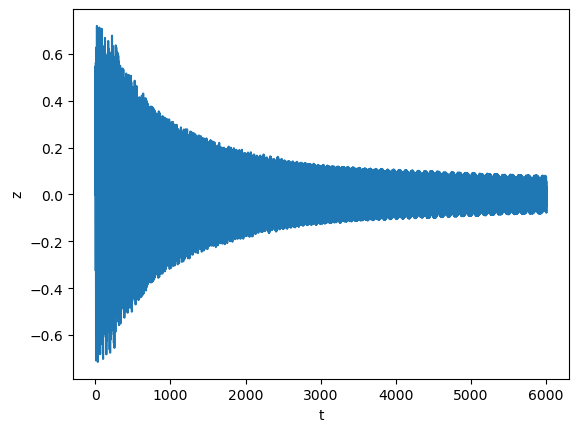

In [29]:
# We test what happens under a small perturbation
eps = 1e-2

make_tz_plot(t0 =  4.151723040306713 + eps*random.random(), z0 =  0,  v0 =  0.8765252436612816 + eps*random.random(), T = 6000)

z0 =  0 v0 =  0.6341583858383621 t0 =  6.1673540234527735


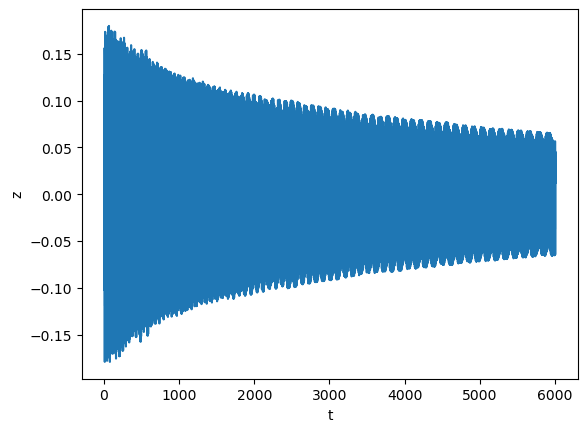

z0 =  0 v0 =  0.34359693440986416 t0 =  3.1384979005624527


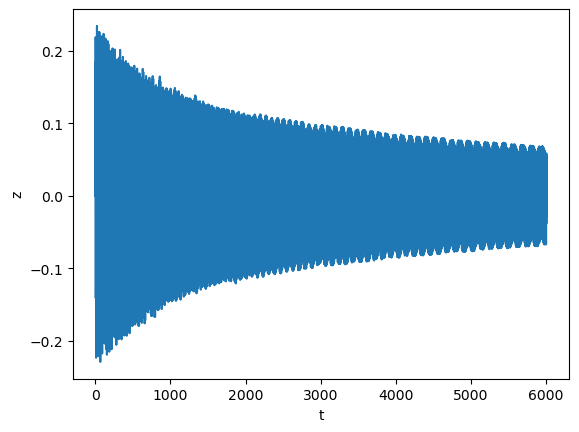

z0 =  0 v0 =  0.9287176819286759 t0 =  5.350088401294281


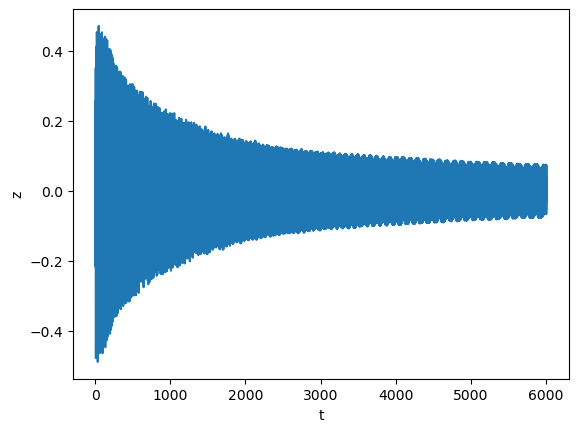

In [31]:
import random
N = 3
for i in range(N):
    z0 = 0
    v0 = 1.0*random.random()
    t0 = 2*np.pi*random.random()
    print("z0 = ", z0, "v0 = ", v0, "t0 = ", t0)
    make_tz_plot(t0,z0,v0, T = 6000)


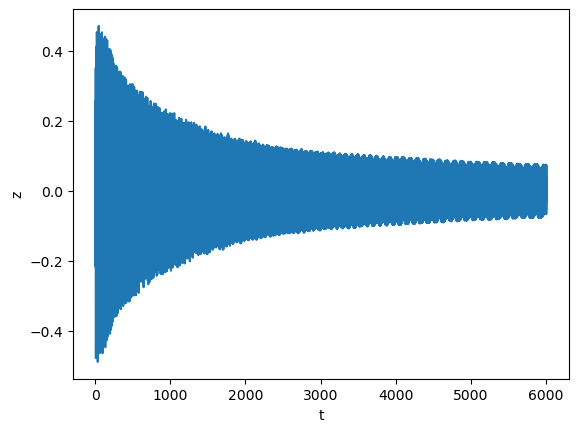

In [3]:
make_tz_plot(t0 =  5.350088401294281, z0 =  0,  v0 =  0.9287176819286759, T = 6000)

C:\Users\leona\AppData\Local\Temp\ipykernel_13384\4125561900.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


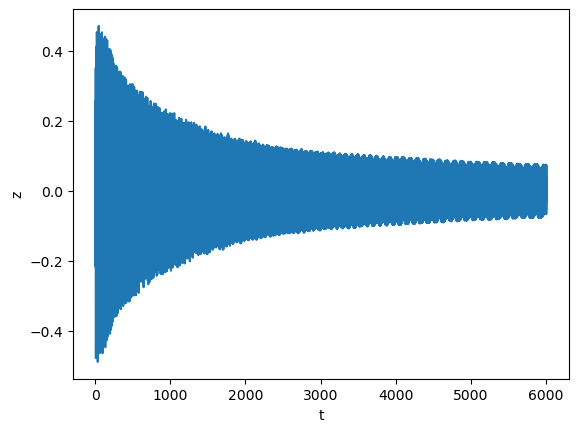

In [4]:
t0 =  5.350088401294281
z0 =  0
v0 =  0.9287176819286759
T = 6000

e = 0.5
sit.set_eps(e)

ans = solve_ivp(fun = sit.phase_velocity, 
                t_span = (t0, t0 + T),
                y0 = np.array([z0, v0]),
                dense_output=True
                )

plt.plot(ans.t, ans.y[0])
plt.xlabel("t")
plt.ylabel("z")
fig = plt.gcf()

from tools.save_figure import save_figure
save_figure(fig, fig_dir_name="figures", prefix = "Oscillation_collapse#")

fig.show()

C:\Users\leona\AppData\Local\Temp\ipykernel_13384\932162960.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


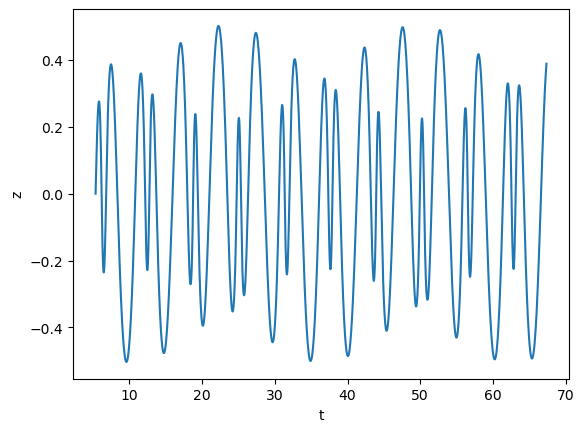

In [28]:
t0 =  5.350088401294281
z0 =  0
v0 =  0.9287176819286759
T = 62

e = 0.5
sit.set_eps(e)

ans = solve_ivp(fun = sit.phase_velocity, 
                t_span = (t0, t0 + T),
                y0 = np.array([z0, v0]),
                rtol = 1e-9,
                atol = 1e-16
                )

plt.plot(ans.t, ans.y[0])
plt.xlabel("t")
plt.ylabel("z")
fig = plt.gcf()


fig.show()

In [29]:
print(ans)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 5.350e+00  5.350e+00 ...  6.732e+01  6.735e+01]
        y: [[ 0.000e+00  1.000e-07 ...  3.799e-01  3.891e-01]
            [ 9.287e-01  9.287e-01 ...  2.894e-01  2.590e-01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 16814
     njev: 0
      nlu: 0


At 6 function eval per timestep, nfev = 1.5*10^4 yields 2.5*10^3 timesteps for T = 100 periods, so 25 timesteps per period, dt = 0.04 periods (alternative times yield the same ratio, so in general for sitnikov, rtol = 1e-3, dt = 0.04).
If the relative error is 1e-3 and we have 2.5*10^3 steps, we enter the range of unity errors. In fact, we enter this range at only 40 periods.

Note as RK45 is a 5th order method, the local error grows like dt^6. This means we can reduce errors by a factor of 10^{-6} at only a 10x increase in nfev.

From now on, I recommend estimating conservatively around 10^2 timesteps per period, yielding a total error of 10^2*#Periods*max{rtol*max|y|, atol}.
In this case, we probably want to stay with errors below 1e-6. Supposing we do at most 1e6 periods, this would mean atol = 1e-14, rtol*max|y| = 1e-14.




## Very small oscillations regime, $v0 \approx 0.1$, long term $T=3000$

z0 =  0 v0 =  0.11608946685498664 t0 =  0.28495886596339326


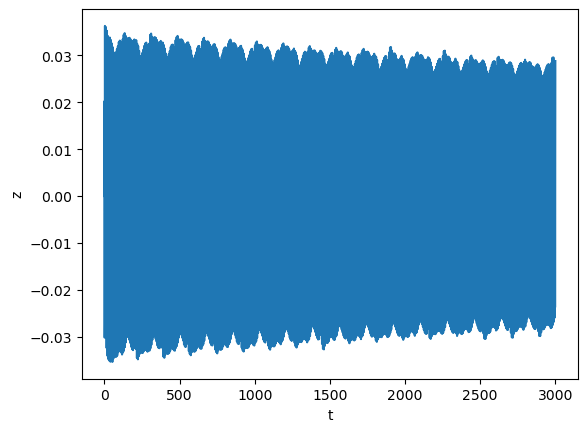

z0 =  0 v0 =  0.10655314864844499 t0 =  5.368880517597372


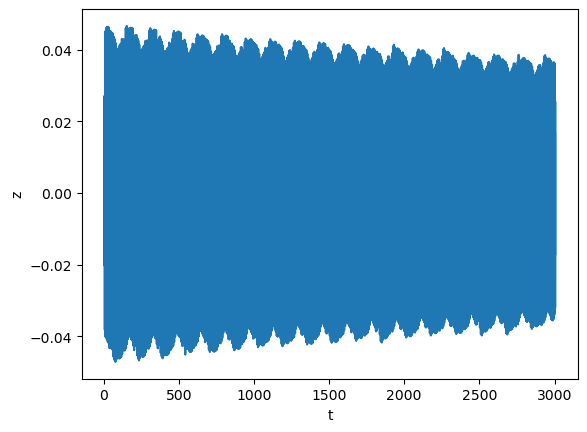

z0 =  0 v0 =  0.10747839356355707 t0 =  2.187927683973152


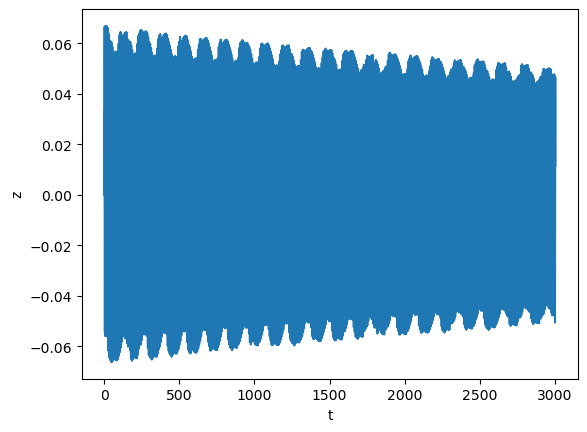

In [32]:
N = 3
for i in range(N):
    z0 = 0
    v0 = 0.1 + 0.02*random.random()
    t0 = 2*np.pi*random.random()
    print("z0 = ", z0, "v0 = ", v0, "t0 = ", t0)
    make_tz_plot(t0,z0,v0, T = 3000)


## Intermediate oscillation regime

Iteration i =  0
z0 =  0 v0 =  1.1478329162940433 t0 =  1.6886173766867019


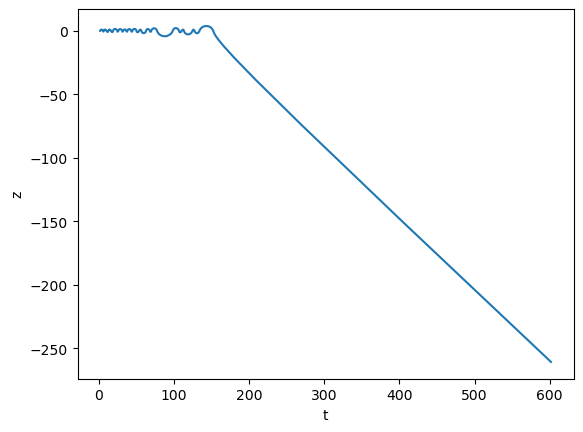

Iteration i =  10
z0 =  0 v0 =  1.147178647836163 t0 =  1.7580876647727555


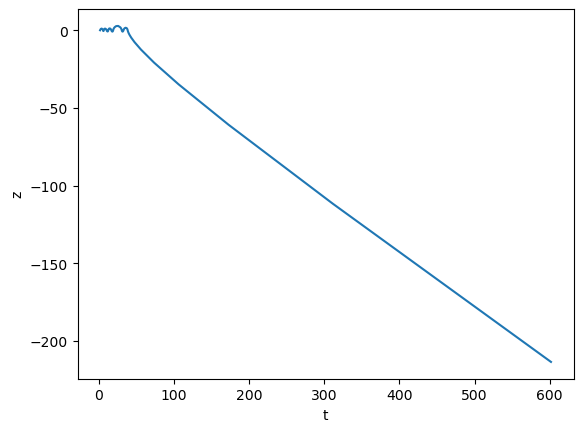

Iteration i =  20
z0 =  0 v0 =  1.1445677383553683 t0 =  1.579048619344217


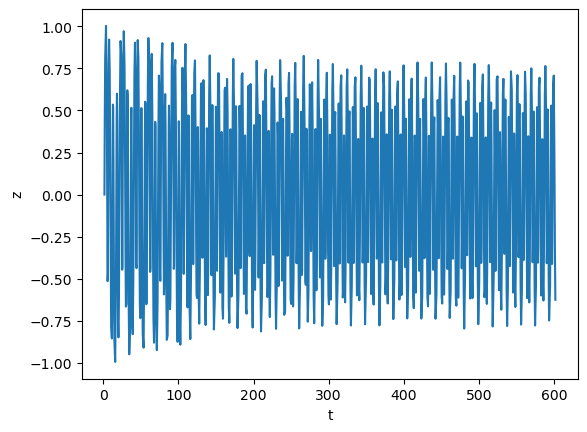



Percentage of escaped:  0.5333333333333333


In [ ]:

# Escape percentage for v0 in (1.14, 1.15) and t0 in (pi/2, pi/2 + 0.2)

N = 30

e = 0.5
sit.set_eps(e)

v0_min = 1.14
v0_var = 0.01
t0_min = np.pi/2
t0_var = 0.2
T = 600


escape_cutoff = 50
N_esc = 0

for i in range(N):
    z0 = 0
    v0 = v0_min + v0_var*random.random()
    t0 = t0_min + t0_var*random.random()

    ans = solve_ivp(fun = sit.phase_velocity, 
                    t_span = (t0, t0 + T),
                    y0 = np.array([z0, v0]),
                    dense_output=True
                    )

    if np.abs(ans.y[0,-1]) > escape_cutoff:
        N_esc = N_esc + 1

    if i%10 == 0:
        print("Iteration i = ", i)
        print("z0 = ", z0, "v0 = ", v0, "t0 = ", t0)
        plt.plot(ans.t, ans.y[0])
        plt.xlabel("t")
        plt.ylabel("z")
        plt.show()


print("\n\nPercentage of escaped: ", N_esc/N)


Iteration i =  0
z0 =  0 v0 =  1.1520262895268152 t0 =  1.7206731314196866


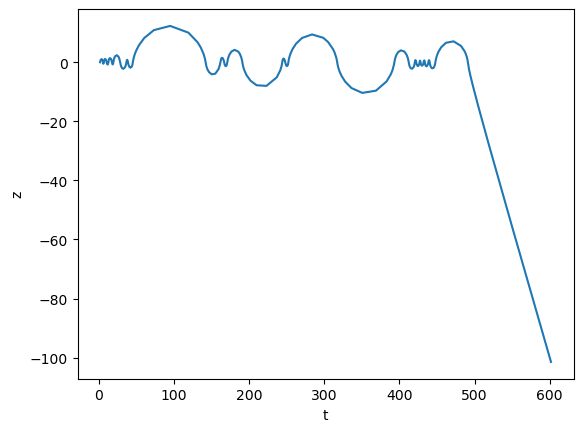

Iteration i =  10
z0 =  0 v0 =  1.158522989826671 t0 =  1.6687602529436634


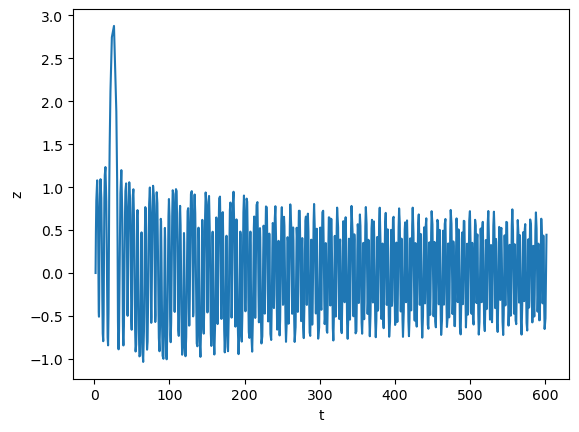

Iteration i =  20
z0 =  0 v0 =  1.1562533058635838 t0 =  1.7263332566457925


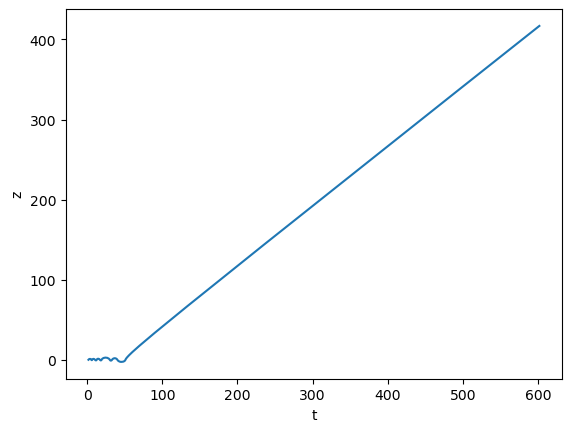



Percentage of escaped:  0.7666666666666667


In [ ]:

# Escape percentage for v0 in (1.15, 1.16) and t0 in (pi/2, pi/2 + 0.2)


N = 30

e = 0.5
sit.set_eps(e)

v0_min = 1.15
v0_var = 0.01
t0_min = np.pi/2
t0_var = 0.2
T = 600


escape_cutoff = 50
N_esc = 0

for i in range(N):
    z0 = 0
    v0 = v0_min + v0_var*random.random()
    t0 = t0_min + t0_var*random.random()

    ans = solve_ivp(fun = sit.phase_velocity, 
                    t_span = (t0, t0 + T),
                    y0 = np.array([z0, v0]),
                    dense_output=True
                    )

    if np.abs(ans.y[0,-1]) > escape_cutoff:
        N_esc = N_esc + 1

    if i%10 == 0:
        print("Iteration i = ", i)
        print("z0 = ", z0, "v0 = ", v0, "t0 = ", t0)
        plt.plot(ans.t, ans.y[0])
        plt.xlabel("t")
        plt.ylabel("z")
        plt.show()


print("\n\nPercentage of escaped: ", N_esc/N)


## Energy plots

In [ ]:
def integrate(t0, z0, v0, T = 600):
    ans = solve_ivp(fun = sit.phase_velocity,
                    t_span = (t0, t0 + T),
                    y0 = np.array(z0, v0),
                    dense_output= True)
    
    return ans.t, ans.y


t, y = integrate(t0, z0, v0)

H = 0.5*y[1]**2 - y[0]/(y[0]**2 + sit.r())
    